In [1]:
%run general_functions.ipynb

In [2]:
vars = {
    'ALK': {'var_name': 'ALK',      'long': 'Alkalinity',                 'unit': r'μ mol $\mathregular{kg^{-1}}$'},
    'DIC': {'var_name': 'DIC',      'long': 'Dissolved Inorganic Carbon', 'unit': r'μ mol $\mathregular{kg^{-1}}$'},
    'mld': {'var_name': 'somxl010', 'long': 'Mixed Layer Depth',          'unit_chg': 'm'},
}

scenarios = {'126':'SSP1-2.6','370':'SSP3-7.0'}
sims = {'baseline':'Baseline','oae':'OAE'}

weights = (grid_cell_ocean.sel(x=slice(520, 595), y=slice(330, 435))).fillna(0)

alk_mask = xr.open_dataset(data_path + '../alk_mask/alkalinity_mask_timeseries.nc')['alk_flux'].sum('time_counter')
alk_mask = alk_mask.where(alk_mask)
alk_mask = (alk_mask.sel(x=slice(520, 595), y=slice(330, 435))).fillna(0)

month_label = ['J','F','M','A','M','J','J','A','S','O','N','D']

3.0467727
3.0467727
3.0467727
3.0467727
3.0467727
3.0467727
3.0467727
3.0467727


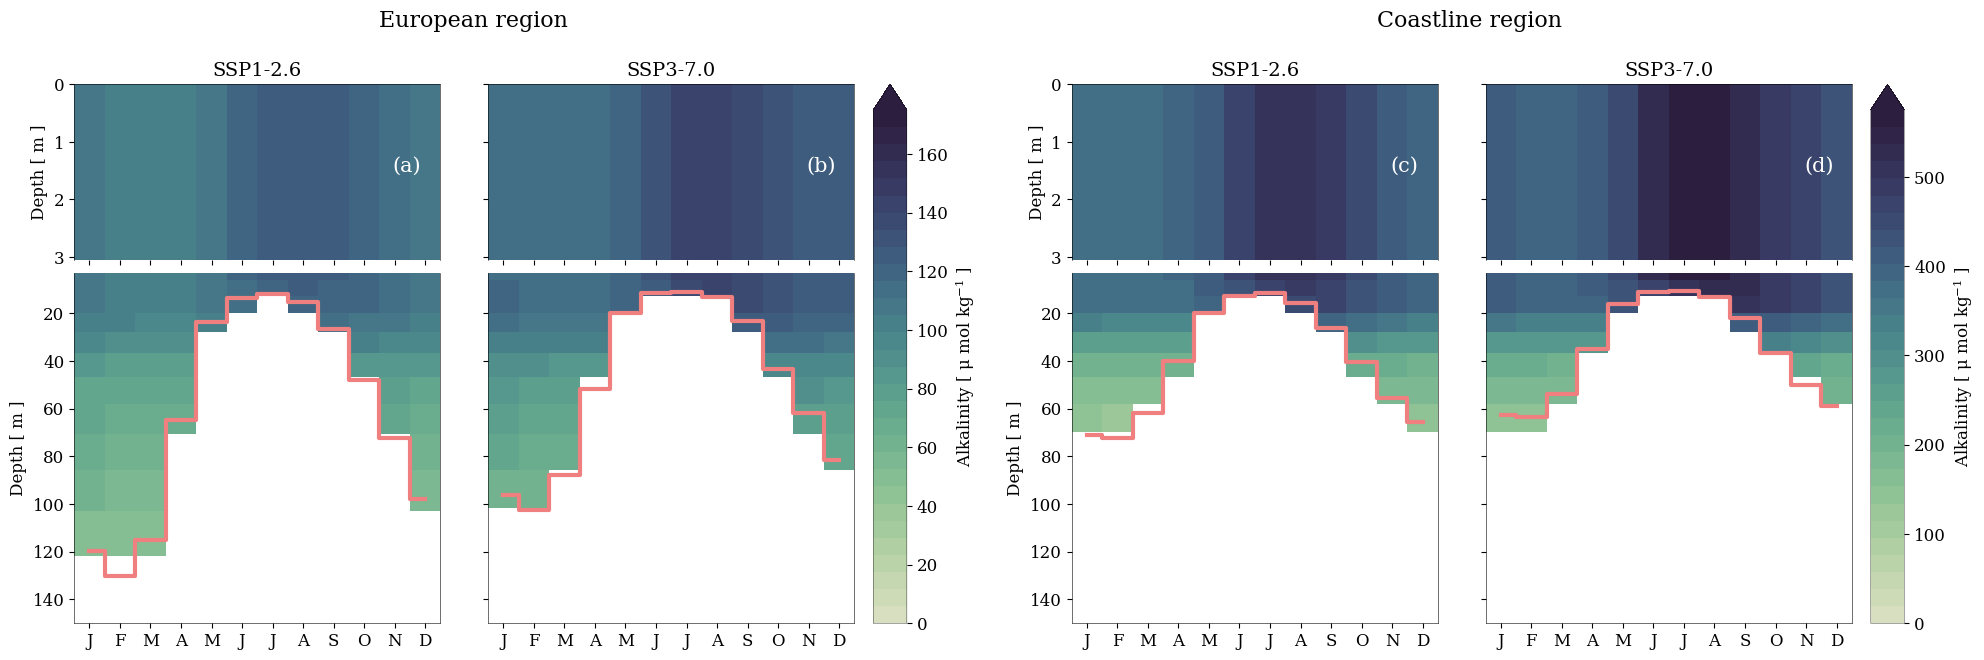

In [4]:
fig, axes = plt.subplots(
    2, len(scenarios) * 2,
    sharex=True,
    figsize=(25, 7),
    gridspec_kw={'height_ratios':[1,2], 'hspace':0.05, 'wspace':0.13}
)


def hovmoller_difference(location, vmin, vmax, axes):
    
    for col, (scen, scen_name) in enumerate(scenarios.items()):
    
        sim_final = {}
        mld_final = {}
    
        ax_top = axes[0, col]
        ax_bot = axes[1, col]
    
        for sim, sim_name in sims.items():
    
            cmap = sns.cubehelix_palette(start=.5, rot=-.75, as_cmap=True)
            cmap, norm = create_discrete_cmap(cmap, 30)
    
            # ---- Load datasets
            mld = xr.open_dataset(f"{data_path}mld_{sim}_{scen}.nc")
            if location == 'Coastline region':
                mld = mld.where(alk_mask)
    
            weighted = mld.weighted(weights).mean(('x','y'))
            final_mld = seasonal_avg(weighted, 'somxl010')
            mld_final[sim] = final_mld
    
            var = 'ALK'
            alkalinity = xr.open_dataset(f"{data_path}{var}_{sim}_{scen}.nc")
            d_1 = alkalinity[var]['deptht'][0].values

            if location == 'Coastline region':
                alkalinity = alkalinity.where(alk_mask)
    
            weighted = alkalinity.weighted(weights).mean(('x','y'))
            final = seasonal_avg(weighted, var)
            final = final.where(final['deptht'] < final_mld['somxl010'], drop=True)
    
            sim_final[sim] = final
        
        baseline, oae = sim_final.keys()
        difference = sim_final[oae][var] - sim_final[baseline][var]
    
        mld_base, mld_oae = mld_final.keys()
        mld_base = mld_final[mld_base]['somxl010']
    
        # ---- TOP
        im_top = difference.T.plot(
            ax=ax_top,
            vmin=vmin,
            vmax=vmax,
            cmap=cmap,
            add_colorbar=False
        )
    
        # ---- BOTTOM
        im_bot = difference.T.plot(
            ax=ax_bot,
            vmin=vmin,
            vmax=vmax,
            cmap=cmap,
            add_colorbar=False
        )
    
        ax_bot.step(mld_base['month'], mld_base - d_1, color='lightcoral', where='mid', linewidth=3)
    
        # ---- Broken axis
        first_level = final['deptht'][0]
        ax_top.set_ylim(first_level, 0)
        ax_bot.set_ylim(150, first_level)
    
        ax_top.spines['bottom'].set_visible(False)
        ax_bot.spines['top'].set_visible(False)
    
        for ax in [ax_top, ax_bot]:
            ax.set_xticks(np.arange(1,13,1))
            ax.set_xticklabels(month_label, fontsize=10)
            ax.set_xlabel('')
            map_outlook(ax,12)
    
        if col != 0:
            for ax in [ax_top, ax_bot]:
                ax.set_ylabel('')
                ax.tick_params(axis='y', labelleft=False)
        else:
            ax_top.set_ylabel('Depth [ m ]')
            ax_bot.set_ylabel('Depth [ m ]')
    
        ax_top.set_title(scen_name, fontsize=14)
    
    cb = fig.colorbar(im_bot, ax=axes, aspect=16, location='right', extend='max', pad=0.02)
    cb.set_label(f'{vars[var]["long"]} [ {vars[var]["unit"]} ]')

    for label in (cb.ax.get_xticklabels() + cb.ax.get_yticklabels() + [cb.ax.title, cb.ax.xaxis.label, cb.ax.yaxis.label]):
        label.set_fontproperties(font_prop)
        label.set_fontsize(12)
    cb.outline.set_linewidth(0.25)
    
    ax = axes[0, 0]
    ax.text(
        10.5, -1, f"{location}",
        # va='center',
        # ha='left',
        fontsize=16,
    ) 
    
for col in range(axes.shape[1]):
    ax = axes[0, col]  # top subplot of each column
    ax.text(
        0.87, 0.5,
        f"({string.ascii_lowercase[col]})",
        transform=ax.transAxes, color='white'
    )
for ax in axes.flatten():
    fineline(ax,0.4)   

ncol = len(scenarios)

# Left half → European
hovmoller_difference('European region', 0, 175, axes[:, :ncol])

# Right half → Coastline
hovmoller_difference('Coastline region', 0, 575, axes[:, ncol:])

plt.savefig(f"/Users/chiaraciscato/Desktop/GEOMAR/2025_ciscato_oae_seasonality/out/figure4.png")